
# ModernBERT Classifier Demo

This notebook fine-tunes `answerdotai/ModernBERT-base` as a tiny binary classifier.

Demo task:

- `luna` = simple / bounded software task
- `astra` = complex / security-sensitive / architectural task

The goal is to show how a small encoder model can replace an LLM for a narrow classification task.

> In Colab, enable a GPU from **Runtime → Change runtime type → T4 GPU** before training.


In [1]:

!pip -q install -U "transformers>=4.48.0" datasets accelerate scikit-learn "matplotlib==3.10.5"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 104.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 116.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 125.3 MB/s eta 0:00:0000:0100:01


## 1. Create a tiny demo dataset

In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split

examples = [
    # Luna: simple / bounded
    ("Fix a typo in the README.", 0),
    ("Change the primary button color from blue to green.", 0),
    ("Rename a local variable for clarity.", 0),
    ("Add a missing unit test for an existing helper.", 0),
    ("Update an API error message.", 0),
    ("Add pagination to an existing endpoint.", 0),
    ("Refactor duplicate validation logic into a shared helper.", 0),
    ("Add structured logging around failed HTTP requests.", 0),
    ("Update the OAuth login page copy without changing authentication logic.", 0),
    ("Rename the authentication middleware function without changing behavior.", 0),
    ("Add a runtime-only field to the User object that is not persisted.", 0),
    ("Add another field to an API response using data already in memory.", 0),
    ("Improve the wording of a validation error.", 0),
    ("Add a new test case for an existing endpoint.", 0),
    ("Document how to run the development server.", 0),
    ("Extract a small helper function without changing behavior.", 0),

    # Astra: complex / risky
    ("Implement Google OAuth login and persist users in PostgreSQL.", 1),
    ("Add refresh token rotation and revocation.", 1),
    ("Migrate user IDs from integers to UUIDs.", 1),
    ("Replace session authentication with JWT authentication.", 1),
    ("Add role-based access control for admins and normal users.", 1),
    ("Create an audit log table and record security-sensitive user actions.", 1),
    ("Add an encrypted API key field to the User model and persist it.", 1),
    ("Redesign the authorization layer across multiple services.", 1),
    ("Implement password reset using signed expiring tokens.", 1),
    ("Add multi-tenant permissions and migrate existing authorization data.", 1),
    ("Change token issuance rules and refresh-token storage.", 1),
    ("Move authentication state from database-backed sessions to stateless tokens.", 1),
    ("Add a new persisted field to User and write the required database migration.", 1),
    ("Introduce an event-driven workflow across the API and worker services.", 1),
    ("Split the monolith authentication module into separate services.", 1),
    ("Add end-to-end encryption for stored customer credentials.", 1),
]

df = pd.DataFrame(examples, columns=["text", "label"])

train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    stratify=df["label"],
)

print("Train:", len(train_df))
print("Test:", len(test_df))
display(train_df.head())


Train: 24
Test: 8


,text,label
30,Split the monolith authentication module into ...,1
9,Rename the authentication middleware function ...,0
18,Migrate user IDs from integers to UUIDs.,1
0,Fix a typo in the README.,0
19,Replace session authentication with JWT authen...,1


## 2. Load ModernBERT

In [3]:

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

MODEL_NAME = "answerdotai/ModernBERT-base"

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label={0: "luna", 1: "astra"},
    label2id={"luna": 0, "astra": 1},
)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256,
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)


CUDA available: True
GPU: Tesla T4


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/8 [00:00<?, ? examples/s]

## 3. Fine-tune the classifier

In [4]:

import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0,
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir="./modernbert-demo",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=1,
    report_to="none",
    bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
    fp16=torch.cuda.is_available() and not torch.cuda.is_bf16_supported(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.858398,0.755371,0.500000,0.000000,0.000000,0.000000
2,0.379150,0.635498,0.750000,1.000000,0.500000,0.666667
3,0.400757,0.594971,0.875000,1.000000,0.750000,0.857143


TrainOutput(global_step=9, training_loss=0.5627848307291666, metrics={'train_runtime': 2.1362, 'train_samples_per_second': 33.704, 'train_steps_per_second': 4.213, 'total_flos': 782678177568.0, 'train_loss': 0.5627848307291666, 'epoch': 3.0})

### Fine-tuning graphs

Run the next cell after training to plot training/evaluation loss, evaluation accuracy/precision/recall/F1, and the learning-rate schedule. Training is logged every optimizer step; evaluation metrics are recorded at the end of each epoch.

You can rerun this cell without retraining, or run it after interrupting training to inspect the metrics collected so far. These curves use the tiny demo holdout set and are not a reliable benchmark.

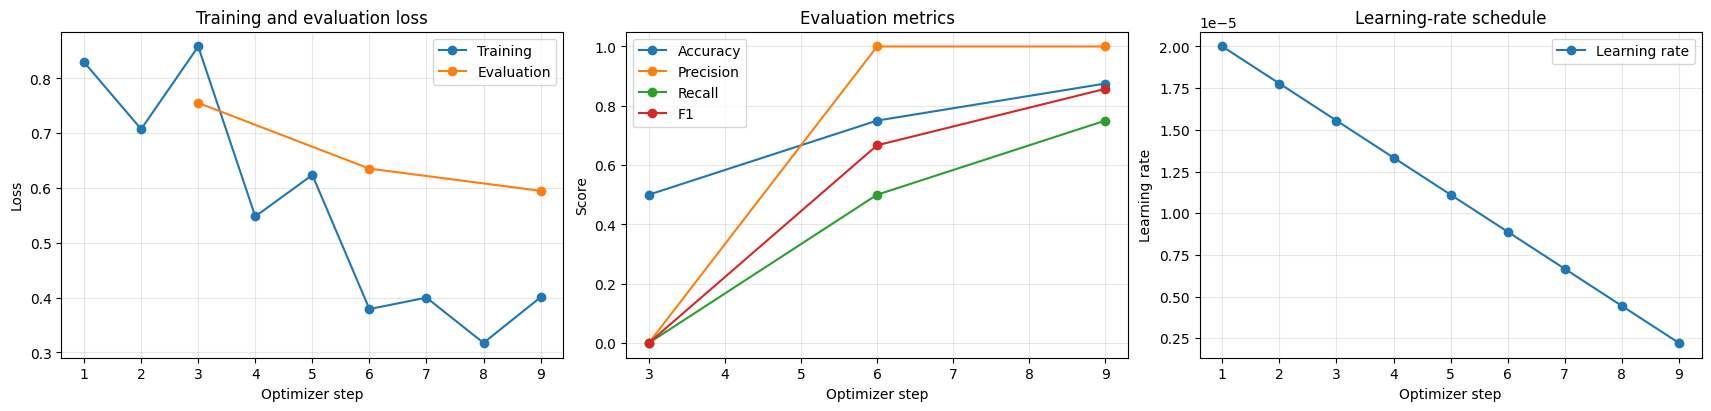

In [5]:
import matplotlib.pyplot as plt

history = trainer.state.log_history

if not history:
    print("No training metrics yet. Run the fine-tuning cell first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4), layout="constrained")
    panels = [
        ("Training and evaluation loss", "Loss", [
            ("loss", "Training"),
            ("eval_loss", "Evaluation"),
        ]),
        ("Evaluation metrics", "Score", [
            ("eval_accuracy", "Accuracy"),
            ("eval_precision", "Precision"),
            ("eval_recall", "Recall"),
            ("eval_f1", "F1"),
        ]),
        ("Learning-rate schedule", "Learning rate", [
            ("learning_rate", "Learning rate"),
        ]),
    ]

    for ax, (title, ylabel, metrics) in zip(axes, panels):
        for key, label in metrics:
            points = [row for row in history if key in row and "step" in row]
            if points:
                ax.plot(
                    [row["step"] for row in points],
                    [row[key] for row in points],
                    marker="o",
                    label=label,
                )
        ax.set(title=title, xlabel="Optimizer step", ylabel=ylabel)
        ax.grid(True, alpha=0.3)
        if ax.lines:
            ax.legend()
        else:
            ax.text(0.5, 0.5, "No metrics logged yet", ha="center", va="center", transform=ax.transAxes)

    axes[1].set_ylim(-0.05, 1.05)
    axes[2].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    plt.show()
    plt.close(fig)

## 4. Evaluate

In [ ]:

metrics = trainer.evaluate()
metrics


## 5. Classify new tasks

In [6]:

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

def classify(text: str):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256,
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits[0]

    probs = torch.softmax(logits, dim=-1)

    result = {
        model.config.id2label[i]: float(probs[i])
        for i in range(len(probs))
    }

    prediction = max(result, key=result.get)

    return {
        "prediction": prediction,
        "confidence": result[prediction],
        "probabilities": result,
    }

classify(
    "Implement OAuth authentication and add a PostgreSQL migration for refresh tokens."
)


{'prediction': 'astra',
 'confidence': 0.7019892334938049,
 'probabilities': {'luna': 0.2980107367038727, 'astra': 0.7019892334938049}}

## 6. Try some differently-worded examples

In [7]:

tests = [
    "Please clean up the docs and correct a spelling mistake.",
    "Users should be able to sign in with Google and their linked identity must be stored.",
    "Add a computed property to User that only exists while the app is running.",
    "Change how refresh tokens are generated, stored, and revoked.",
    "Add one more assertion to the existing test suite.",
]

for text in tests:
    result = classify(text)
    print("\n", text)
    print(result)



 Please clean up the docs and correct a spelling mistake.
{'prediction': 'luna', 'confidence': 0.5608540773391724, 'probabilities': {'luna': 0.5608540773391724, 'astra': 0.43914595246315}}

 Users should be able to sign in with Google and their linked identity must be stored.
{'prediction': 'astra', 'confidence': 0.7213507294654846, 'probabilities': {'luna': 0.2786492109298706, 'astra': 0.7213507294654846}}

 Add a computed property to User that only exists while the app is running.
{'prediction': 'luna', 'confidence': 0.7908132076263428, 'probabilities': {'luna': 0.7908132076263428, 'astra': 0.2091868370771408}}

 Change how refresh tokens are generated, stored, and revoked.
{'prediction': 'astra', 'confidence': 0.5137904286384583, 'probabilities': {'luna': 0.48620954155921936, 'astra': 0.5137904286384583}}

 Add one more assertion to the existing test suite.
{'prediction': 'luna', 'confidence': 0.5946763157844543, 'probabilities': {'luna': 0.5946763157844543, 'astra': 0.405323684215


## What to do next

This dataset is intentionally tiny, so treat the result as a functional demo rather than a meaningful benchmark.

For a real experiment:

1. Collect **500–5,000+** labeled examples.
2. Keep paraphrases from the same underlying task in the same train/test split.
3. Add lots of **hard negatives**.
4. Evaluate on genuinely unseen wording.
5. Add probability calibration before using confidence thresholds in production.

You can reuse the same notebook for email intent classification by replacing the dataset and labels.
